# 04 – Visualisation des données Mastodon

Ce notebook présente une synthèse visuelle des données produites par les différentes étapes du projet.

Les visualisations s'appuient sur les données stockées dans PostgreSQL par :

- le pipeline de streaming ;
- les traitements batch ;
- le modèle de Machine Learning d'analyse de sentiment.

L'objectif est de représenter de manière claire :

- l'évolution de l'activité Mastodon dans le temps ;
- les utilisateurs les plus actifs ;
- les hashtags les plus fréquents ;
- les caractéristiques des publications ;
- la répartition des sentiments prédits ;
- certaines analyses croisées entre activité et sentiment.

In [1]:
import os
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt

## 1 – Connexion à PostgreSQL

Les visualisations sont construites à partir des données déjà produites par les différentes parties du projet et stockées dans PostgreSQL.

Cette première étape permet de vérifier la connexion à la base et la présence des tables nécessaires à l'analyse.

In [2]:
conn = psycopg2.connect(
    host=os.getenv("PGHOST"),
    port=os.getenv("PGPORT"),
    database=os.getenv("PGDATABASE"),
    user=os.getenv("PGUSER"),
    password=os.getenv("PGPASSWORD")
)

cursor = conn.cursor()

cursor.execute("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'public'
    ORDER BY table_name;
""")

tables = cursor.fetchall()

print("Connexion PostgreSQL réussie ✅")
print("\nTables disponibles :")

for table in tables:
    print("-", table[0])

cursor.close()
conn.close()

Connexion PostgreSQL réussie ✅

Tables disponibles :
- streaming_posts_per_hour
- streaming_user_stats_hourly
- toot_sentiments
- toots


### 1.1 – Fonction de lecture des données

Afin de simplifier la création des visualisations, une fonction permet d'exécuter une requête SQL sur PostgreSQL et de récupérer directement le résultat dans un DataFrame pandas.

In [6]:
def lire_postgres(requete):
    conn = psycopg2.connect(
        host=os.getenv("PGHOST"),
        port=os.getenv("PGPORT"),
        database=os.getenv("PGDATABASE"),
        user=os.getenv("PGUSER"),
        password=os.getenv("PGPASSWORD")
    )

    try:
        cursor = conn.cursor()
        cursor.execute(requete)

        colonnes = [
            description[0]
            for description in cursor.description
        ]

        donnees = cursor.fetchall()

        return pd.DataFrame(
            donnees,
            columns=colonnes
        )

    finally:
        cursor.close()
        conn.close()

In [19]:
resume = lire_postgres("""
    SELECT
        COUNT(*) AS total_toots,
        COUNT(DISTINCT user_id) AS total_utilisateurs,
        COUNT(*) FILTER (WHERE language = 'en') AS toots_anglais,
        MIN(created_at) AS premier_toot,
        MAX(created_at) AS dernier_toot
    FROM toots;
""")

display(resume)

,total_toots,total_utilisateurs,toots_anglais,premier_toot,dernier_toot
0,262,144,201,2026-10-02 21:29:50.734192,2026-10-09 09:47:11.624


## 2 – Évolution de l'activité dans le temps

Le pipeline de streaming calcule le nombre de publications Mastodon en anglais par fenêtre d'une heure.

Ces agrégations sont enregistrées dans la table `streaming_posts_per_hour` et permettent de visualiser l'évolution de l'activité au cours du temps sans recalculer les fenêtres dans ce notebook.

In [8]:
activite_horaire = lire_postgres("""
    SELECT
        window_start,
        window_end,
        post_count
    FROM streaming_posts_per_hour
    ORDER BY window_start;
""")

print("Nombre de fenêtres horaires :", len(activite_horaire))

display(activite_horaire)

Nombre de fenêtres horaires : 4


,window_start,window_end,post_count
0,2026-10-08 12:00:00,2026-10-08 13:00:00,13
1,2026-10-08 13:00:00,2026-10-08 14:00:00,63
2,2026-10-09 07:00:00,2026-10-09 08:00:00,23
3,2026-10-09 08:00:00,2026-10-09 09:00:00,41


### 2.1 – Nombre de publications par heure

Le graphique suivant représente le nombre de publications Mastodon en anglais observées dans chaque fenêtre horaire calculée par le pipeline de streaming.

Les données proviennent directement de la table `streaming_posts_per_hour`, produite par Spark Structured Streaming.

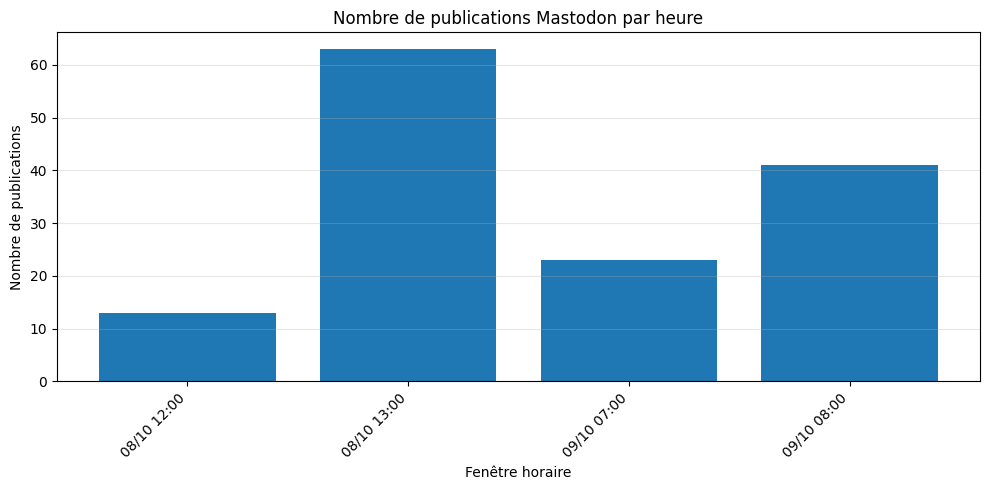

In [9]:
activite_horaire["window_start"] = pd.to_datetime(
    activite_horaire["window_start"]
)

activite_horaire["heure"] = (
    activite_horaire["window_start"]
    .dt.strftime("%d/%m %H:%M")
)

plt.figure(figsize=(10, 5))

plt.bar(
    activite_horaire["heure"],
    activite_horaire["post_count"]
)

plt.title("Nombre de publications Mastodon par heure")
plt.xlabel("Fenêtre horaire")
plt.ylabel("Nombre de publications")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 3 – Analyse de l'activité des utilisateurs

Le traitement batch analyse l'activité des utilisateurs en comptant le nombre de publications associées à chaque compte.

Cette visualisation reprend cet indicateur afin d'identifier les comptes les plus actifs parmi les publications réellement collectées depuis Mastodon.

In [10]:
utilisateurs_actifs = lire_postgres("""
    SELECT
        user_id,
        username,
        COUNT(*) AS nb_toots
    FROM toots
    WHERE toot_id NOT IN ('1001', '1002', '1003', '1004', '1005')
    GROUP BY user_id, username
    ORDER BY nb_toots DESC
    LIMIT 10;
""")

display(utilisateurs_actifs)

,user_id,username,nb_toots
0,116450756112437762,techwire@gamefan.net,23
1,116070447239053927,feed@igeek.gamer-geek-news.com,20
2,115061140460610278,hackaday@www.urbanmind.net,16
3,117079923873198049,berktech,6
4,112026408859289825,brewotaku,4
5,116457563306148173,fast_company@robot.villas,4
6,116701981151890111,top_news,4
7,114727403638487044,aisight,3
8,116398605837443627,Pulrepo,3
9,109293500780368127,dkluft@mastodon.sdf.org,3


### 3.1 – Utilisateurs les plus actifs

Le graphique suivant représente les dix comptes ayant publié le plus de toots dans les données collectées.

Les données de démonstration sont exclues afin de ne conserver que les publications réellement récupérées depuis Mastodon.

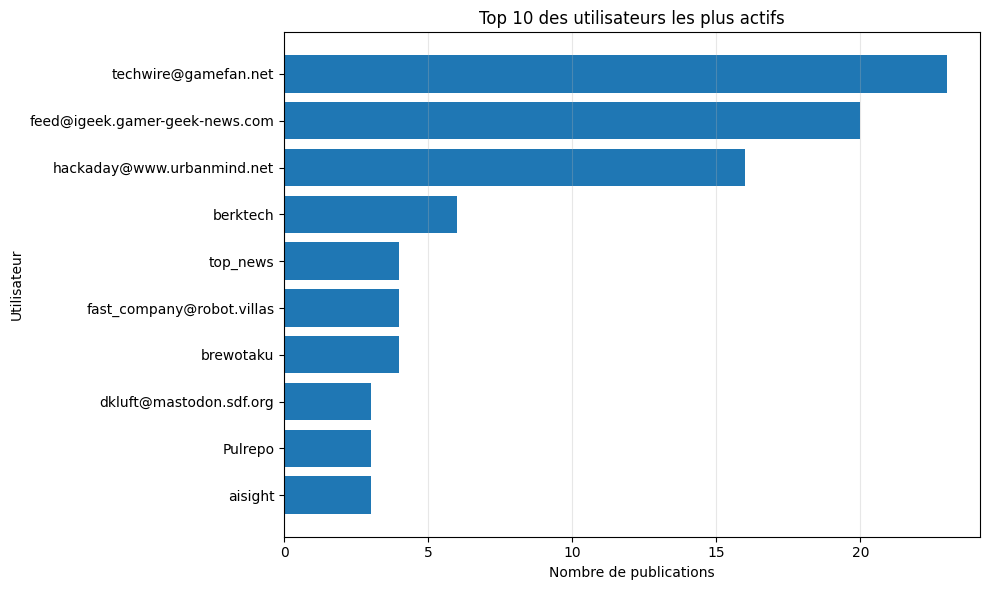

In [11]:
utilisateurs_graphique = (
    utilisateurs_actifs
    .sort_values("nb_toots", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    utilisateurs_graphique["username"],
    utilisateurs_graphique["nb_toots"]
)

plt.title("Top 10 des utilisateurs les plus actifs")
plt.xlabel("Nombre de publications")
plt.ylabel("Utilisateur")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 4 – Analyse des hashtags

Le traitement batch identifie les hashtags les plus fréquemment présents dans les publications Mastodon.

Cette analyse permet de mettre en évidence les principaux sujets associés aux publications collectées autour de l'intelligence artificielle.

In [12]:
hashtags_frequents = lire_postgres("""
    SELECT
        LOWER(TRIM(hashtag)) AS hashtag,
        COUNT(*) AS nb_occurrences
    FROM toots
    CROSS JOIN LATERAL UNNEST(hashtags) AS hashtag
    WHERE toot_id NOT IN ('1001', '1002', '1003', '1004', '1005')
      AND hashtag IS NOT NULL
      AND TRIM(hashtag) <> ''
    GROUP BY LOWER(TRIM(hashtag))
    ORDER BY nb_occurrences DESC
    LIMIT 15;
""")

display(hashtags_frequents)

,hashtag,nb_occurrences
0,ai,209
1,software,42
2,tech,36
3,technology,30
4,google,29
5,cybersecurity,29
6,microsoft,28
7,technews,28
8,apple,26
9,gadgets,25


### 4.1 – Hashtags les plus fréquents hors hashtags de collecte

Les publications ont été collectées autour du hashtag `#AI`.

Afin d'éviter que les hashtags directement liés au critère de collecte dominent la visualisation, `#ai` et `#artificialintelligence` sont exclus du classement.

Le graphique met ainsi davantage en évidence les thématiques associées à l'intelligence artificielle dans les publications collectées.

In [13]:
hashtags_graphique = lire_postgres("""
    SELECT
        LOWER(TRIM(hashtag)) AS hashtag,
        COUNT(*) AS nb_occurrences
    FROM toots
    CROSS JOIN LATERAL UNNEST(hashtags) AS hashtag
    WHERE toot_id NOT IN ('1001', '1002', '1003', '1004', '1005')
      AND hashtag IS NOT NULL
      AND TRIM(hashtag) <> ''
      AND LOWER(TRIM(hashtag)) NOT IN ('ai', 'artificialintelligence')
    GROUP BY LOWER(TRIM(hashtag))
    ORDER BY nb_occurrences DESC
    LIMIT 10;
""")

display(hashtags_graphique)

,hashtag,nb_occurrences
0,software,42
1,tech,36
2,technology,30
3,google,29
4,cybersecurity,29
5,microsoft,28
6,technews,28
7,apple,26
8,startup,25
9,gadgets,25


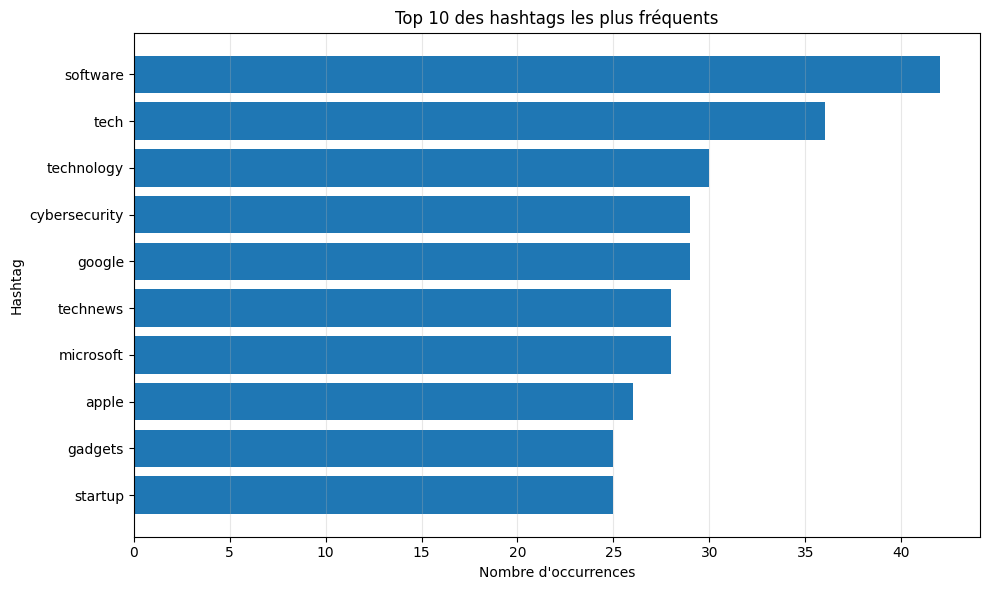

In [14]:
hashtags_graphique_trie = (
    hashtags_graphique
    .sort_values("nb_occurrences", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    hashtags_graphique_trie["hashtag"],
    hashtags_graphique_trie["nb_occurrences"]
)

plt.title("Top 10 des hashtags les plus fréquents")
plt.xlabel("Nombre d'occurrences")
plt.ylabel("Hashtag")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 5 – Analyse de la longueur des publications

Le traitement batch calcule la longueur des publications Mastodon à partir du nombre de caractères contenus dans chaque toot.

Cette visualisation cherche à observer s'il existe une relation entre **l'activité d'un utilisateur** et **la longueur moyenne de ses publications**.

Afin d'éviter de tirer des conclusions à partir d'un seul message, seuls les utilisateurs ayant publié au moins deux toots sont conservés.


In [16]:
longueur_utilisateurs = lire_postgres("""
    SELECT
        username,
        COUNT(*) AS nb_toots,
        ROUND(AVG(LENGTH(content))::numeric, 1) AS longueur_moyenne
    FROM toots
    WHERE toot_id NOT IN ('1001', '1002', '1003', '1004', '1005')
      AND content IS NOT NULL
    GROUP BY username
    HAVING COUNT(*) >= 2
    ORDER BY nb_toots DESC;
""")

display(longueur_utilisateurs)

,username,nb_toots,longueur_moyenne
0,techwire@gamefan.net,27,435.3
1,feed@igeek.gamer-geek-news.com,26,385.5
2,hackaday@www.urbanmind.net,17,1322.4
3,berktech,6,345.2
4,brewotaku,5,335.2
5,Pulrepo,4,472.8
6,aisight,4,394.5
7,fast_company@robot.villas,4,162.0
8,top_news,4,368.5
9,sipirtu,3,309.3


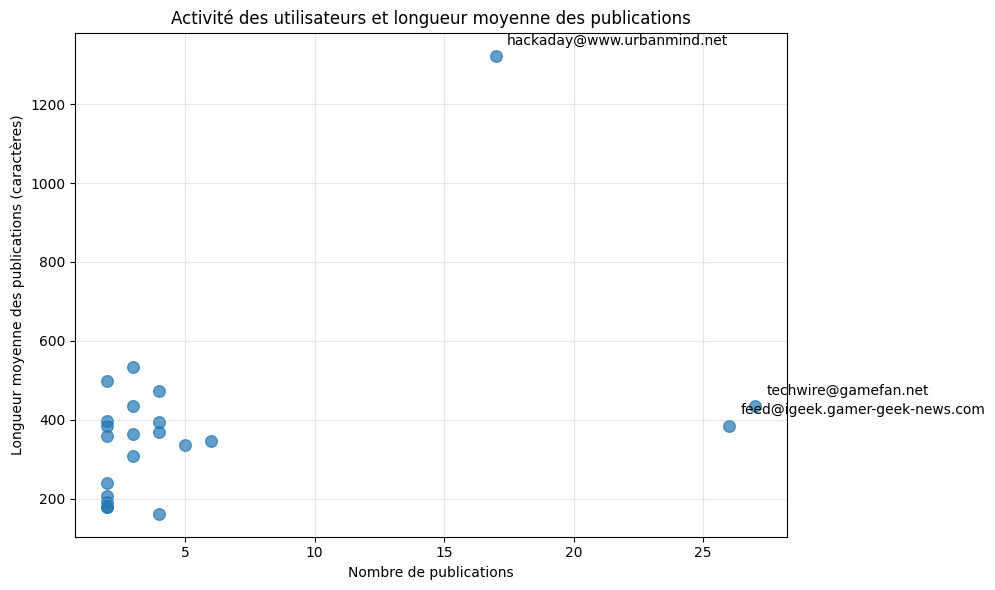

In [20]:
# Conversion des colonnes numériques
longueur_utilisateurs["nb_toots"] = pd.to_numeric(
    longueur_utilisateurs["nb_toots"]
)

longueur_utilisateurs["longueur_moyenne"] = pd.to_numeric(
    longueur_utilisateurs["longueur_moyenne"]
)

# Création du graphique
plt.figure(figsize=(10, 6))

plt.scatter(
    longueur_utilisateurs["nb_toots"],
    longueur_utilisateurs["longueur_moyenne"],
    s=70,
    alpha=0.7
)

# Utilisateur avec les publications les plus longues en moyenne
plus_long = longueur_utilisateurs.loc[
    longueur_utilisateurs["longueur_moyenne"].idxmax()
]

plt.annotate(
    plus_long["username"],
    (
        plus_long["nb_toots"],
        plus_long["longueur_moyenne"]
    ),
    xytext=(8, 8),
    textcoords="offset points"
)

# Deux utilisateurs les plus actifs
plus_actifs = longueur_utilisateurs.nlargest(
    2,
    "nb_toots"
)

for _, row in plus_actifs.iterrows():
    plt.annotate(
        row["username"],
        (
            row["nb_toots"],
            row["longueur_moyenne"]
        ),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.title(
    "Activité des utilisateurs et longueur moyenne des publications"
)

plt.xlabel("Nombre de publications")
plt.ylabel("Longueur moyenne des publications (caractères)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
correlation = longueur_utilisateurs[
    ["nb_toots", "longueur_moyenne"]
].corr().iloc[0, 1]

print(
    f"Corrélation entre activité et longueur moyenne : "
    f"{correlation:.3f}"
)

Corrélation entre activité et longueur moyenne : 0.402


In [22]:
sans_outlier = longueur_utilisateurs[
    longueur_utilisateurs["username"] != "hackaday@www.urbanmind.net"
]

correlation_sans_outlier = sans_outlier[
    ["nb_toots", "longueur_moyenne"]
].corr().iloc[0, 1]

print(
    f"Corrélation avec tous les utilisateurs : "
    f"{correlation:.3f}"
)

print(
    f"Corrélation sans l'utilisateur atypique : "
    f"{correlation_sans_outlier:.3f}"
)

Corrélation avec tous les utilisateurs : 0.402
Corrélation sans l'utilisateur atypique : 0.235


### Interprétation

Le coefficient de corrélation entre le nombre de publications et leur longueur moyenne est de **0,402** sur l'ensemble des utilisateurs étudiés.

Cependant, un utilisateur présente une longueur moyenne de publication nettement supérieure au reste de l'échantillon. Lorsque cet utilisateur atypique est exclu du calcul, la corrélation diminue à **0,235**.

La relation entre le niveau d'activité d'un utilisateur et la longueur moyenne de ses publications apparaît donc **faible**. Le nombre de publications ne permet pas, à lui seul, d'expliquer la longueur des contenus publiés.

Cette analyse doit également être interprétée avec prudence compte tenu du nombre limité de publications collectées.

## 6 – Analyse des sentiments

Le modèle de Machine Learning entraîné dans le notebook `03_ml.ipynb` produit une prédiction de sentiment pour les publications Mastodon en anglais.

Avant de visualiser les résultats, on vérifie que les publications collectées disposent bien d'une prédiction enregistrée dans la table `toot_sentiments`.

In [24]:
couverture_sentiments = lire_postgres("""
    SELECT
        COUNT(*) AS toots_anglais_reels,
        COUNT(s.toot_id) AS toots_avec_sentiment,
        COUNT(*) - COUNT(s.toot_id) AS toots_sans_sentiment
    FROM toots t
    LEFT JOIN toot_sentiments s
        ON t.toot_id = s.toot_id
    WHERE t.language = 'en'
      AND t.toot_id NOT IN ('1001', '1002', '1003', '1004', '1005');
""")

display(couverture_sentiments)

,toots_anglais_reels,toots_avec_sentiment,toots_sans_sentiment
0,206,206,0


### 6.1 – Répartition des sentiments prédits

Le modèle de Machine Learning classe chaque publication anglaise selon deux classes apprises : positive ou négative.

Une catégorie supplémentaire `uncertain` est utilisée pour l'affichage lorsque la probabilité prédite se situe dans une zone intermédiaire. Elle permet d'éviter de présenter comme certaines des prédictions pour lesquelles le modèle est moins confiant.

La visualisation suivante présente la répartition des sentiments sur l'ensemble des publications anglaises réellement collectées.

In [25]:
repartition_sentiments = lire_postgres("""
    SELECT
        sentiment_display,
        COUNT(*) AS nb_toots
    FROM toot_sentiments
    GROUP BY sentiment_display
    ORDER BY nb_toots DESC;
""")

display(repartition_sentiments)

,sentiment_display,nb_toots
0,positive,156
1,negative,30
2,uncertain,20


In [26]:
total_sentiments = repartition_sentiments["nb_toots"].sum()

print("Nombre total de toots avec sentiment :", total_sentiments)

Nombre total de toots avec sentiment : 206


### 6.2 – Visualisation de la répartition des sentiments

Le graphique suivant représente la part des publications classées comme `positive`, `negative` ou `uncertain`.

Cette représentation est adaptée ici car elle permet de visualiser simplement la proportion de chaque catégorie dans l'ensemble des publications anglaises analysées.

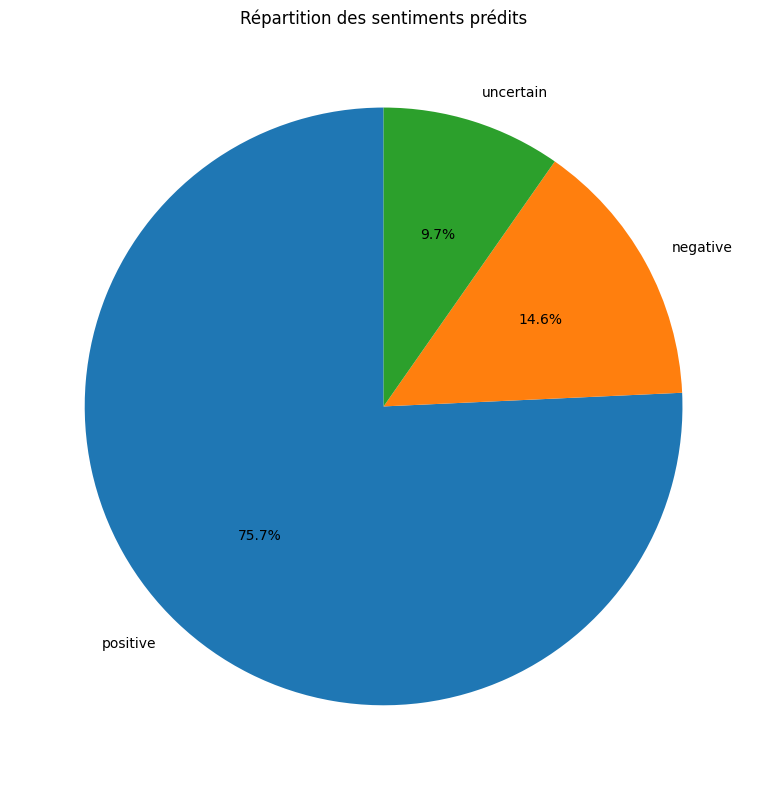

In [27]:
plt.figure(figsize=(8, 8))

plt.pie(
    repartition_sentiments["nb_toots"],
    labels=repartition_sentiments["sentiment_display"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des sentiments prédits")

plt.tight_layout()
plt.show()

### 6.3 – Répartition des sentiments par utilisateur

Cette analyse compare la répartition des sentiments prédits pour les utilisateurs les plus actifs.

Seules les publications anglaises ayant reçu une prédiction de sentiment sont prises en compte.

Afin de limiter l'influence des comptes ayant publié très peu de messages, seuls les utilisateurs disposant d'au moins trois publications analysées sont conservés.

In [28]:
sentiments_utilisateurs = lire_postgres("""
    SELECT
        t.username,
        COUNT(*) AS total_toots,

        COUNT(*) FILTER (
            WHERE s.sentiment_display = 'positive'
        ) AS nb_positive,

        COUNT(*) FILTER (
            WHERE s.sentiment_display = 'negative'
        ) AS nb_negative,

        COUNT(*) FILTER (
            WHERE s.sentiment_display = 'uncertain'
        ) AS nb_uncertain

    FROM toots t
    INNER JOIN toot_sentiments s
        ON t.toot_id = s.toot_id

    WHERE t.language = 'en'
      AND t.toot_id NOT IN ('1001', '1002', '1003', '1004', '1005')

    GROUP BY t.username

    HAVING COUNT(*) >= 3

    ORDER BY total_toots DESC
    LIMIT 10;
""")

display(sentiments_utilisateurs)

,username,total_toots,nb_positive,nb_negative,nb_uncertain
0,techwire@gamefan.net,31,28,3,0
1,feed@igeek.gamer-geek-news.com,28,25,3,0
2,hackaday@www.urbanmind.net,20,16,3,1
3,brewotaku,6,5,1,0
4,researchbuzz_firehose@rbfirehose.com,4,3,0,1
5,sipirtu,4,3,1,0
6,top_news,4,4,0,0
7,dkluft@mastodon.sdf.org,3,2,0,1
8,Econopass@flipboard.com,3,3,0,0


### 6.4 – Comparaison du profil de sentiment des utilisateurs

Le nombre de publications varie fortement selon les utilisateurs.

Afin de comparer leur profil de sentiment indépendamment de leur niveau d'activité, les nombres de publications positives, négatives et incertaines sont transformés en pourcentages.

Chaque barre représente ainsi 100 % des publications analysées pour un utilisateur.

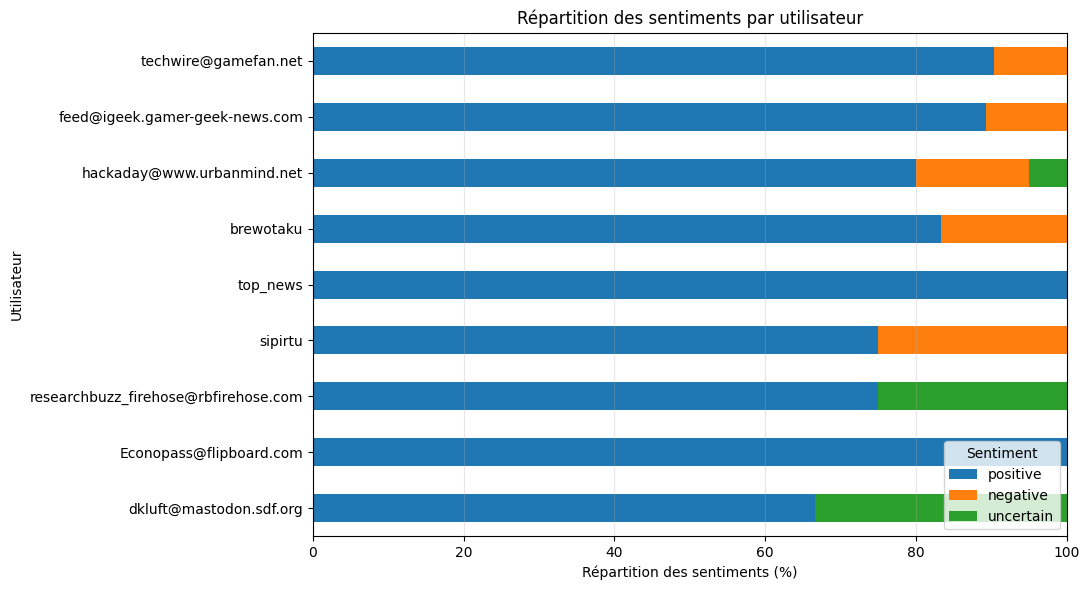

In [29]:
sentiments_graphique = sentiments_utilisateurs.copy()

# Conversion des colonnes en valeurs numériques
colonnes_numeriques = [
    "total_toots",
    "nb_positive",
    "nb_negative",
    "nb_uncertain"
]

for colonne in colonnes_numeriques:
    sentiments_graphique[colonne] = pd.to_numeric(
        sentiments_graphique[colonne]
    )

# Calcul des proportions
sentiments_graphique["positive"] = (
    sentiments_graphique["nb_positive"]
    / sentiments_graphique["total_toots"]
    * 100
)

sentiments_graphique["negative"] = (
    sentiments_graphique["nb_negative"]
    / sentiments_graphique["total_toots"]
    * 100
)

sentiments_graphique["uncertain"] = (
    sentiments_graphique["nb_uncertain"]
    / sentiments_graphique["total_toots"]
    * 100
)

# Tri pour le graphique horizontal
sentiments_graphique = sentiments_graphique.sort_values(
    "total_toots",
    ascending=True
)

# Création du graphique
ax = (
    sentiments_graphique
    .set_index("username")[
        ["positive", "negative", "uncertain"]
    ]
    .plot(
        kind="barh",
        stacked=True,
        figsize=(11, 6)
    )
)

ax.set_title(
    "Répartition des sentiments par utilisateur"
)

ax.set_xlabel("Répartition des sentiments (%)")
ax.set_ylabel("Utilisateur")

ax.set_xlim(0, 100)

ax.legend(
    title="Sentiment",
    loc="lower right"
)

ax.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 6.5 – Évolution des sentiments dans le temps

Cette analyse observe l'évolution des sentiments prédits au cours du temps.

Les publications sont regroupées par heure afin de comparer le nombre de messages positifs, négatifs et incertains sur les différentes périodes de collecte.

In [30]:
sentiments_temps = lire_postgres("""
    SELECT
        DATE_TRUNC('hour', t.created_at) AS heure,
        s.sentiment_display,
        COUNT(*) AS nb_toots
    FROM toots t
    INNER JOIN toot_sentiments s
        ON t.toot_id = s.toot_id
    WHERE t.language = 'en'
      AND t.toot_id NOT IN ('1001', '1002', '1003', '1004', '1005')
    GROUP BY
        DATE_TRUNC('hour', t.created_at),
        s.sentiment_display
    ORDER BY heure, sentiment_display;
""")

display(sentiments_temps)

,heure,sentiment_display,nb_toots
0,2026-10-08 12:00:00,positive,12
1,2026-10-08 12:00:00,uncertain,1
2,2026-10-08 13:00:00,negative,8
3,2026-10-08 13:00:00,positive,48
4,2026-10-08 13:00:00,uncertain,7
5,2026-10-08 16:00:00,positive,1
6,2026-10-09 06:00:00,uncertain,1
7,2026-10-09 07:00:00,negative,3
8,2026-10-09 07:00:00,positive,18
9,2026-10-09 07:00:00,uncertain,2


### 6.6 – Évolution horaire du profil de sentiment

Une heatmap est utilisée pour observer comment la répartition des sentiments évolue selon les différentes périodes de collecte.

Pour chaque heure, les nombres de publications sont convertis en pourcentages. Cette normalisation permet de comparer le profil de sentiment des différentes périodes indépendamment du volume de publications collectées.

Le nombre total de publications de chaque heure est également indiqué afin de conserver le contexte nécessaire à l'interprétation.

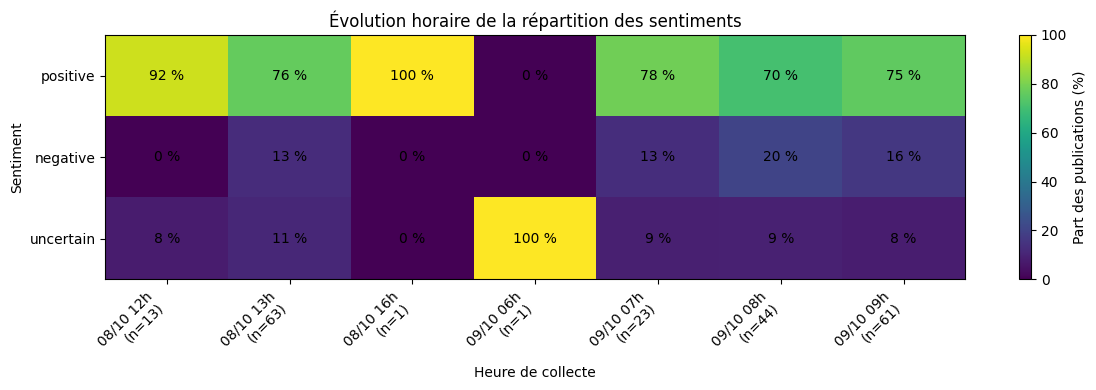

In [31]:
# Conversion de la date
sentiments_temps["heure"] = pd.to_datetime(
    sentiments_temps["heure"]
)

# Transformation en tableau :
# lignes = sentiments
# colonnes = heures
heatmap_sentiments = sentiments_temps.pivot(
    index="sentiment_display",
    columns="heure",
    values="nb_toots"
).fillna(0)

# Ordre fixe des sentiments
heatmap_sentiments = heatmap_sentiments.reindex(
    ["positive", "negative", "uncertain"]
)

# Nombre total de publications pour chaque heure
totaux_heures = heatmap_sentiments.sum(axis=0)

# Transformation en pourcentage pour chaque heure
heatmap_pourcentages = (
    heatmap_sentiments
    .div(totaux_heures, axis=1)
    * 100
)

# Création des libellés de l'axe X
labels_heures = [
    f"{heure.strftime('%d/%m %Hh')}\n(n={int(totaux_heures[heure])})"
    for heure in heatmap_pourcentages.columns
]

# Création de la heatmap
fig, ax = plt.subplots(figsize=(12, 4))

image = ax.imshow(
    heatmap_pourcentages.values,
    aspect="auto"
)

# Axes
ax.set_xticks(range(len(labels_heures)))
ax.set_xticklabels(
    labels_heures,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(heatmap_pourcentages.index)))
ax.set_yticklabels(
    heatmap_pourcentages.index
)

# Affichage des pourcentages dans les cellules
for i in range(len(heatmap_pourcentages.index)):
    for j in range(len(heatmap_pourcentages.columns)):
        valeur = heatmap_pourcentages.iloc[i, j]

        ax.text(
            j,
            i,
            f"{valeur:.0f} %",
            ha="center",
            va="center"
        )

# Barre de couleur
barre = plt.colorbar(
    image,
    ax=ax
)

barre.set_label(
    "Part des publications (%)"
)

ax.set_title(
    "Évolution horaire de la répartition des sentiments"
)

ax.set_xlabel("Heure de collecte")
ax.set_ylabel("Sentiment")

plt.tight_layout()
plt.show()

### Interprétation

La heatmap montre que le sentiment positif reste majoritaire sur l'ensemble des périodes de collecte disposant d'un volume significatif de publications.

La proportion de publications positives varie cependant selon les heures. Elle atteint notamment **92 %** le 8 octobre à 12 h, contre environ **70 %** le 9 octobre à 8 h. Sur ce dernier créneau, la proportion de publications négatives atteint **20 %**, soit la valeur la plus élevée parmi les périodes comportant plusieurs publications.

Les créneaux du 8 octobre à 16 h et du 9 octobre à 6 h ne contiennent chacun qu'une seule publication. Les valeurs de 100 % observées sur ces périodes ne doivent donc pas être interprétées comme une tendance générale.

Cette analyse met ainsi en évidence une prédominance globale des prédictions positives, tout en montrant que leur répartition peut varier selon les périodes de collecte.

Ces résultats doivent néanmoins être interprétés avec prudence : le modèle a été entraîné sur le jeu de données Sentiment140, alors que les publications Mastodon collectées autour de l'intelligence artificielle sont souvent techniques ou informationnelles. Une prédiction positive ne signifie donc pas nécessairement qu'une publication exprime explicitement une opinion positive.

## 7 – Bilan de l'analyse

Ce notebook a permis de synthétiser visuellement les données produites par les différentes composantes du projet : streaming, traitements batch et Machine Learning.

L'analyse de l'activité Mastodon a mis en évidence plusieurs éléments :

- l'activité varie selon les différentes périodes de collecte ;
- certains comptes publient beaucoup plus fréquemment que les autres ;
- les hashtags associés à l'intelligence artificielle font apparaître des thématiques récurrentes autour de la technologie, du logiciel, de la cybersécurité et des grandes entreprises technologiques ;
- la relation entre le nombre de publications d'un utilisateur et leur longueur moyenne reste faible. Un utilisateur atypique influence notamment le coefficient de corrélation, qui passe de **0,402** à **0,235** lorsqu'il est exclu de l'analyse.

L'analyse de sentiment porte finalement sur **206 publications anglaises** issues de la collecte réelle.

La répartition obtenue est la suivante :

- **156 publications positives**, soit environ **75,7 %** ;
- **30 publications négatives**, soit environ **14,6 %** ;
- **20 publications incertaines**, soit environ **9,7 %**.

Les visualisations montrent que les prédictions positives sont majoritaires chez la plupart des utilisateurs et durant les différentes périodes de collecte. Des variations apparaissent néanmoins selon les comptes et les heures observées.

Ces résultats doivent être interprétés avec prudence. Le volume de données collectées reste limité et certaines périodes ne contiennent que très peu de publications. De plus, le modèle de sentiment a été entraîné sur **Sentiment140**, un jeu de données différent des publications Mastodon techniques et informationnelles analysées dans ce projet. Une prédiction positive ou négative ne représente donc pas nécessairement une opinion explicitement exprimée par l'auteur.

L'ensemble du projet illustre néanmoins une chaîne de traitement complète : **collecte en streaming, stockage dans PostgreSQL, analyse batch avec Spark, application d'un modèle de Machine Learning sauvegardé sur de nouvelles données, puis restitution des résultats sous forme de visualisations**.